### Simple Linear Regression 


In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
## Read the Dataset
df = pd.read_csv("164.1-height_weight.csv")
df.head()

,Height,Weight
0,188,84.2
1,178,76.5
2,164,55.1
3,157,47.4
4,170,76.5


Text(0, 0.5, 'Height')

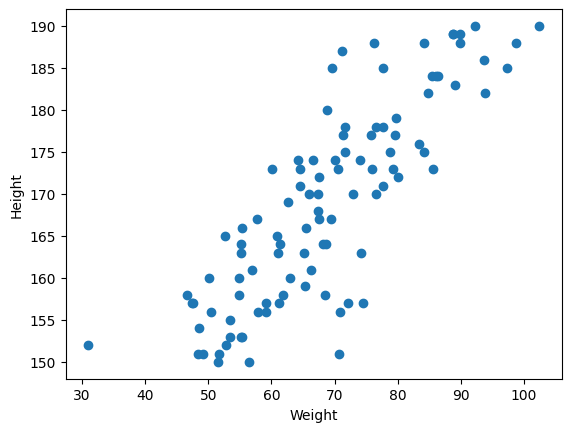

In [5]:
## Scatter plot
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")

In [6]:
## Divide our dataset into independent and dependent features
X = df[['Weight']]
y = df[['Height']]

In [7]:
## Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state = 20)

In [8]:
X.shape

(100, 1)

In [9]:
X_train.shape,X_test.shape

((80, 1), (20, 1))

In [10]:
y_train.shape,y_test.shape

((80, 1), (20, 1))

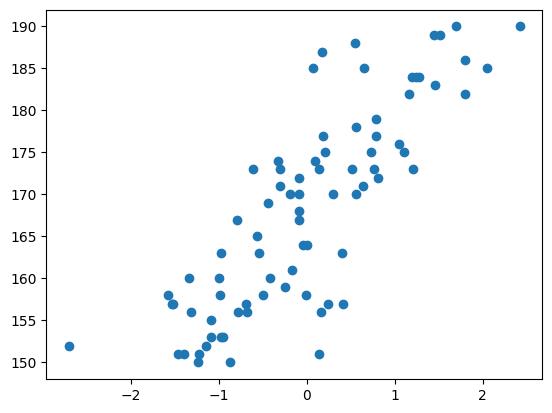

In [11]:
## Standardize the dataset Train independent data
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)
plt.scatter(X_train,y_train)

The Scope or Coefficient of weight is [[9.78452506]]
Intercept: [168.1625]


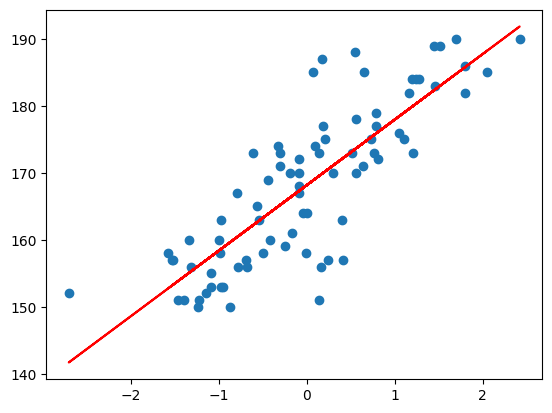

In [12]:
## Train the Simple Linear Regression Model
from sklearn.linear_model import LinearRegression 
regression = LinearRegression()
regression.fit(X_train,y_train)
print("The Scope or Coefficient of weight is",regression.coef_)
print("Intercept:",regression.intercept_)
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train),'r')


In [13]:
## Prediction of train data
# 1. predicted height output = intercept + coef_(weights)
# 2. y_pred_train = 65.4364 + 1.26(X_train)

In [14]:
## Prediction Of the data 
y_pred_test = regression.predict(X_test)
y_pred_test,y_test

(array([[156.85876626],
        [166.70032549],
        [158.61618755],
        [173.09733898],
        [174.50327601],
        [165.64587271],
        [182.23592969],
        [168.66863733],
        [179.07257137],
        [165.85676327],
        [170.28546492],
        [183.07949191],
        [162.9042955 ],
        [154.0468922 ],
        [189.3359117 ],
        [163.0448892 ],
        [159.88153088],
        [168.24685622],
        [158.82707811],
        [171.90229251]]),
     Height
 70     165
 74     174
 2      164
 44     177
 56     178
 48     163
 12     189
 36     167
 0      188
 49     166
 76     178
 93     188
 88     157
 92     154
 5      188
 77     164
 23     161
 63     180
 87     166
 38     174)

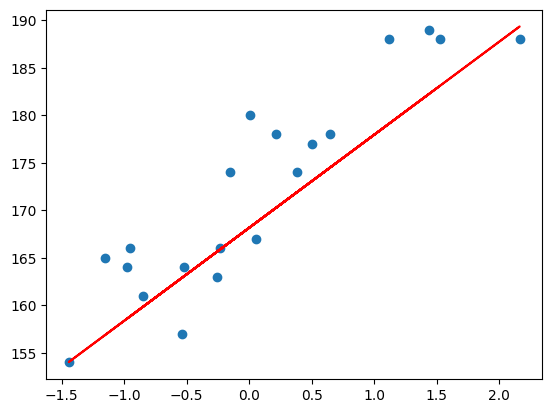

In [15]:
plt.scatter(X_test,y_test)
plt.plot(X_test,regression.predict(X_test),'r')

### Performance Metrics

In [16]:
## MSE,MAE,RMSE
## R_square and Adjusted R_square
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
mse = mean_squared_error(y_test,y_pred_test)
mae = mean_absolute_error(y_test,y_pred_test)
rmse = np.sqrt(mse)

print(mse)
print(mae)
print(rmse)

31.38945755580753
4.569642353647266
5.602629521555707


In [17]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred_test)
score

0.7211003571309222

In [18]:
## Adjusted R_squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.7056059325270846

In [20]:
## New data point weight is 80
scaled_weight = scalar.transform([[80]])
scaled_weight 

c:\Users\gp298\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.81328461]])

In [21]:
print("The predicted height for weight 80 is",regression.predict(scaled_weight))

The predicted height for weight 80 is [[176.1201036]]


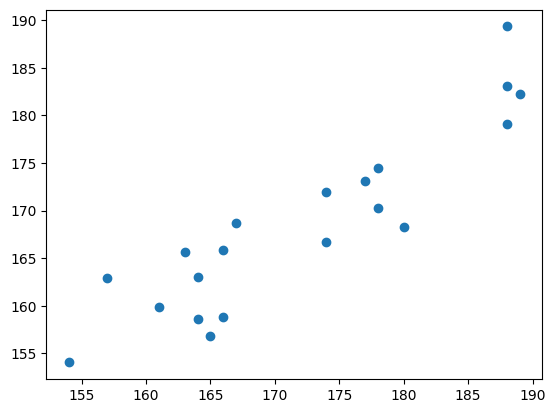

In [22]:
## Assumptions
## Plot scatter plot for the prediction
plt.scatter(y_test,y_pred_test)

In [23]:
## Residuals 
residuals = y_test - y_pred_test
residuals

,Height
70,8.141234
74,7.299675
2,5.383812
44,3.902661
56,3.496724
48,-2.645873
12,6.764070
36,-1.668637
0,8.927429
49,0.143237


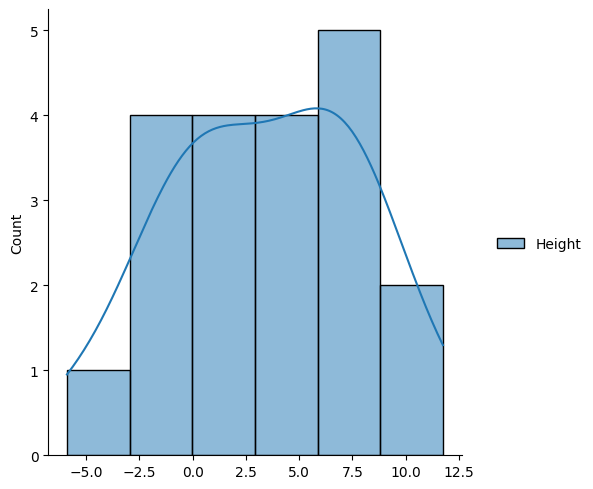

In [24]:
## Plot this residuals
import seaborn as sns
sns.displot(residuals,kde= True)